# Modelling

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
import warnings

warnings.filterwarnings('ignore')

df_rfm = pd.read_csv('data/processed/rfm_behavioral_features.csv')

df_rfm.dropna(inplace=True)
print(f"Total Nasabah/Pelanggan: {df_rfm.shape[0]}")
display(df_rfm.head())

Total Nasabah/Pelanggan: 991945


,Customer_ID,Frequency,Monetary,Avg_Discount_Percent,Avg_Session_Duration,Coupon_Usage_Rate,Recency
0,CUS-9F6Y5,1,503.26,5.0,24.1,0.0,378
1,CUS-8FMW4,1,206.32,0.0,6.3,1.0,202
2,CUS-V17TZ,1,244.54,0.0,7.7,0.0,125
3,CUS-NNQPN,1,177.54,5.0,10.6,0.0,392
4,CUS-2ASFL,1,328.55,10.0,16.7,0.0,80


In [60]:
# # Masukkan semua 6 fitur (RFM + Behavioral)
# features = [
#     'Recency', 'Frequency', 'Monetary', 
#     'Avg_Discount_Percent', 'Avg_Session_Duration', 'Coupon_Usage_Rate'
# ]
# X = df_rfm[features]

# # Standarisasi data 
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)

# print("Data berhasil di-scaling. Bentuk array:", X_scaled.shape) 
# # Pastikan outputnya sekarang berakhiran 6, bukan 3!

In [61]:
from sklearn.preprocessing import PowerTransformer

# Masukkan semua 6 fitur
features = [
    'Recency', 'Frequency', 'Monetary', 
    'Avg_Discount_Percent', 'Avg_Session_Duration', 'Coupon_Usage_Rate'
]
X = df_rfm[features]

pt = PowerTransformer(method='yeo-johnson')
X_transformed = pt.fit_transform(X)

print("Data ditransformasi. Bentuk array:", X_transformed.shape)

Data ditransformasi. Bentuk array: (991945, 6)


Mencari K yang terbaik

In [62]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt

In [63]:
np.random.seed(42)
sample_indices = np.random.choice(len(X_transformed), 50000, replace=False)
X_sampled_eval = X_transformed[sample_indices]

inertia_values = []
silhouette_values = []
davies_values = []

K_range = range(2, 7) 

In [64]:
for k in K_range:
    kmeans_eval = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=10000)
    
    # Fit ke seluruh data untuk akurasi centroid
    kmeans_eval.fit(X_transformed)
    
    labels_sampled = kmeans_eval.predict(X_sampled_eval)
    
    inertia_values.append(kmeans_eval.inertia_)
    sil_score = silhouette_score(X_sampled_eval, labels_sampled)
    db_score = davies_bouldin_score(X_sampled_eval, labels_sampled)
    
    silhouette_values.append(sil_score)
    davies_values.append(db_score)
    
    print(f"K={k} | Silhouette: {sil_score:.4f} | Davies-Bouldin: {db_score:.4f}")


K=2 | Silhouette: 0.2119 | Davies-Bouldin: 1.9286
K=3 | Silhouette: 0.1656 | Davies-Bouldin: 1.9472
K=4 | Silhouette: 0.1647 | Davies-Bouldin: 1.7788
K=5 | Silhouette: 0.1764 | Davies-Bouldin: 1.7452
K=6 | Silhouette: 0.1763 | Davies-Bouldin: 1.6572


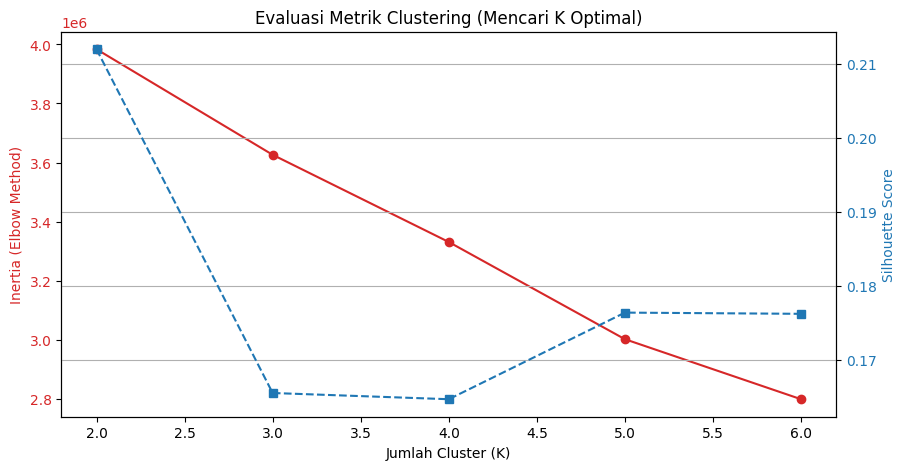

In [65]:
# Visualisasi Hasil Evaluasi
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:red'
ax1.set_xlabel('Jumlah Cluster (K)')
ax1.set_ylabel('Inertia (Elbow Method)', color=color)
ax1.plot(K_range, inertia_values, marker='o', color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel('Silhouette Score', color=color)  
ax2.plot(K_range, silhouette_values, marker='s', linestyle='--', color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Evaluasi Metrik Clustering (Mencari K Optimal)')
plt.grid(True)
plt.show()

In [66]:
# Terapkan PCA menjadi 2 
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_transformed)

# Tambahkan hasil PCA ke dataframe untuk visualisasi
df_rfm['PCA_1'] = X_pca[:, 0]
df_rfm['PCA_2'] = X_pca[:, 1]

explained_variance = pca.explained_variance_ratio_.sum() * 100
print(f"Informasi yang dipertahankan PCA: {explained_variance:.2f}%")

Informasi yang dipertahankan PCA: 41.70%


In [67]:
# Fit & Predict menggunakan K-Means
from sklearn.cluster import KMeans
n_clusters = 4 

# Menggunakan k-means++ agar penentuan titik awal centroid lebih cerdas
kmeans = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42)
df_rfm['Cluster'] = kmeans.fit_predict(X_transformed)

print("=== DISTRIBUSI NASABAH PER CLUSTER ===")
print(df_rfm['Cluster'].value_counts().sort_index())

=== DISTRIBUSI NASABAH PER CLUSTER ===
Cluster
0    194544
1    301588
2    217777
3    278036
Name: count, dtype: int64


In [68]:
# Evaluasi Metrik Clustering
np.random.seed(42)
sample_size = min(20000, len(X_transformed))
sample_indices = np.random.choice(len(X_transformed), sample_size, replace=False)

X_sampled = X_transformed[sample_indices]
labels_sampled = df_rfm['Cluster'].iloc[sample_indices]

sil_score = silhouette_score(X_sampled, labels_sampled)
db_score = davies_bouldin_score(X_sampled, labels_sampled)

print("=== HASIL EVALUASI METRIK ===")
print(f"Silhouette Score : {sil_score:.4f}")
print(f"Davies-Bouldin   : {db_score:.4f}")

=== HASIL EVALUASI METRIK ===
Silhouette Score : 0.1868
Davies-Bouldin   : 1.9409


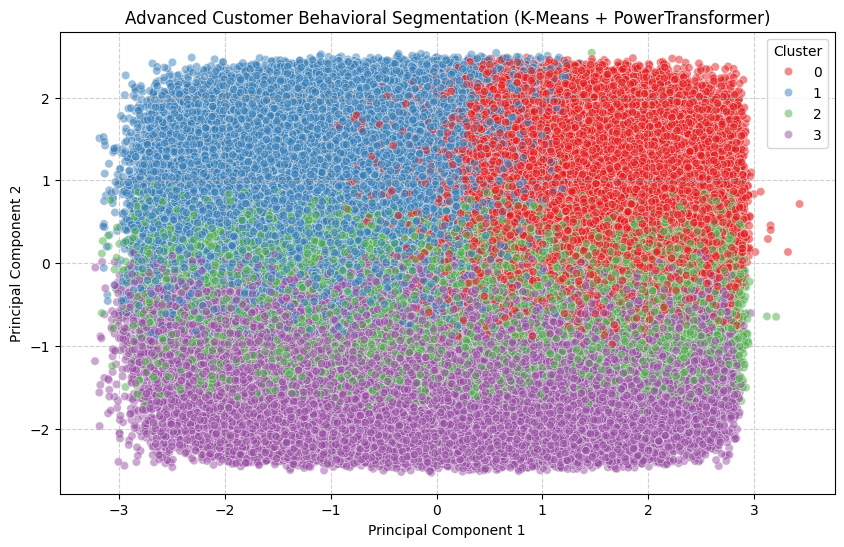

In [78]:
# Visualisasi Hasil Clustering
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='PCA_1', y='PCA_2', 
    hue='Cluster', data=df_rfm, 
    palette='Set1', alpha=0.5
)
plt.title('Advanced Customer Behavioral Segmentation (K-Means + PowerTransformer)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [79]:
# Tabel Profiling Bisnis
cluster_profile = df_rfm.groupby('Cluster')[features].mean().round(2)
cluster_profile['Total_Nasabah'] = df_rfm.groupby('Cluster')['Customer_ID'].count()

print("\n=== PROFIL BISNIS PER CLUSTER ===")
display(cluster_profile)


=== PROFIL BISNIS PER CLUSTER ===


,Recency,Frequency,Monetary,Avg_Discount_Percent,Avg_Session_Duration,Coupon_Usage_Rate,Total_Nasabah
Cluster,,,,,,,
0,363.36,1.01,514.57,1.21,30.47,1.0,194544
1,364.84,1.01,337.56,13.20,30.56,1.0,301588
2,158.40,1.01,411.89,8.54,30.47,0.0,217777
3,524.94,1.00,401.66,8.47,30.52,0.0,278036


In [81]:
# Simpan data hasil clustering untuk pembuatan Dashboard/Website
df_rfm.to_csv('data/processed/clustered_customers_segmentation.csv', index=False)
print("Data dengan label cluster berhasil disimpan!")

Data dengan label cluster berhasil disimpan!


In [71]:
# # 5. Fit & Predict menggunakan K-Means
# n_clusters = 4 

# # Menggunakan k-means++ agar penentuan titik awal centroid lebih cerdas
# kmeans = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42)
# df_rfm['Cluster'] = kmeans.fit_predict(X_transformed)

# print("=== DISTRIBUSI NASABAH PER CLUSTER ===")
# print(df_rfm['Cluster'].value_counts().sort_index())

In [72]:
# # Menentukan jumlah segmentasi pelanggan (cluster)
# n_clusters = 4 

# # Inisialisasi dan fit model GMM
# gmm = GaussianMixture(n_components=n_clusters, covariance_type='full', random_state=42)
# df_rfm['Cluster'] = gmm.fit_predict(X_scaled)

# print("Clustering Selesai! Distribusi Nasabah per Cluster:")
# print(df_rfm['Cluster'].value_counts())

In [73]:
# from sklearn.cluster import KMeans

# n_clusters = 4 

# # Gunakan K-Means biasa setelah data di-transformasi dengan PowerTransformer
# kmeans = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42)
# df_rfm['Cluster'] = kmeans.fit_predict(X_transformed)

# print("Clustering K-Means Selesai! Distribusi Nasabah per Cluster:")
# print(df_rfm['Cluster'].value_counts())

In [74]:
# # Mengambil sampel data untuk mempercepat perhitungan matriks jarak
# sample_size = min(20000, len(X_transformed)) # Ambil maksimal 20rb baris
# np.random.seed(42)
# sample_indices = np.random.choice(len(X_transformed), sample_size, replace=False)

# X_sampled = X_transformed[sample_indices]
# labels_sampled = df_rfm['Cluster'].iloc[sample_indices]

# # Hitung metrik
# sil_score = silhouette_score(X_sampled, labels_sampled)
# db_score = davies_bouldin_score(X_sampled, labels_sampled)

# print(f"Silhouette Score (Sampled): {sil_score:.4f}  <-- Makin dekat ke 1 makin baik")
# print(f"Davies-Bouldin Index      : {db_score:.4f}  <-- Makin dekat ke 0 makin baik")

In [75]:
# # 1. Visualisasi Sebaran Cluster (Menggunakan PCA)
# plt.figure(figsize=(10, 6))
# sns.scatterplot(
#     x='PCA_1', y='PCA_2', 
#     hue='Cluster', data=df_rfm, 
#     palette='Set1', alpha=0.5
# )
# plt.title('Customer Segmentation Map (GMM + PCA)')
# plt.show()

# # Profiling Rata-rata 6 Metrik per Cluster
# fitur_profiling = [
#     'Recency', 'Frequency', 'Monetary', 
#     'Avg_Discount_Percent', 'Avg_Session_Duration', 'Coupon_Usage_Rate'
# ]

# cluster_profile = df_rfm.groupby('Cluster')[fitur_profiling].mean().round(2)
# cluster_profile['Jumlah_Nasabah'] = df_rfm.groupby('Cluster')['Customer_ID'].count()

# print("\n=== PROFIL SEGMENTASI NASABAH (ADVANCED) ===")
# display(cluster_profile)

In [76]:
# # 1. Visualisasi Sebaran Cluster (Menggunakan PCA)
# plt.figure(figsize=(10, 6))
# sns.scatterplot(
#     x='PCA_1', y='PCA_2', 
#     hue='Cluster', data=df_rfm, 
#     palette='Set1', alpha=0.5
# )
# plt.title('Customer Segmentation Map (GMM + PCA)')
# plt.show()

# # Profiling Rata-rata 6 Metrik per Cluster
# fitur_profiling = [
#     'Recency', 'Frequency', 'Monetary', 
#     'Avg_Discount_Percent', 'Avg_Session_Duration', 'Coupon_Usage_Rate'
# ]

# cluster_profile = df_rfm.groupby('Cluster')[fitur_profiling].mean().round(2)
# cluster_profile['Jumlah_Nasabah'] = df_rfm.groupby('Cluster')['Customer_ID'].count()

# print("\n=== PROFIL SEGMENTASI NASABAH (ADVANCED) ===")
# display(cluster_profile)

In [77]:
# # 1. Visualisasi Sebaran Cluster (Menggunakan PCA)
# plt.figure(figsize=(10, 6))
# sns.scatterplot(
#     x='PCA_1', y='PCA_2', 
#     hue='Cluster', data=df_rfm, 
#     palette='Set1', alpha=0.5
# )
# plt.title('Customer Segmentation Map (GMM + PCA)')
# plt.show()

# # 2. Profiling Rata-rata RFM per Cluster
# cluster_profile = df_rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
# cluster_profile['Jumlah_Nasabah'] = df_rfm.groupby('Cluster')['Customer_ID'].count()

# print("\n=== PROFIL SEGMENTASI NASABAH ===")
# display(cluster_profile)